In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

# Style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully')

Libraries loaded successfully


In [ ]:
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 5,630 rows × 20 columns


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [ ]:
# Basic Info
print('=== DATA INFO ===')
df.info()

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  

In [ ]:
# Descriptive Statistics
print('=== DESCRIPTIVE STATISTICS ===')
df.describe().round(2)

=== DESCRIPTIVE STATISTICS ===


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.00,5630.00,5366.00,5630.00,5379.00,5375.00,5630.00,5630.00,5630.00,5630.00,5365.00,5374.00,5372.00,5323.00,5630.00
mean,52815.50,0.17,10.19,1.65,15.64,2.93,3.69,3.07,4.21,0.28,15.71,1.75,3.01,4.54,177.22
std,1625.39,0.37,8.56,0.92,8.53,0.72,1.02,1.38,2.58,0.45,3.68,1.89,2.94,3.65,49.21
min,50001.00,0.00,0.00,1.00,5.00,0.00,1.00,1.00,1.00,0.00,11.00,0.00,1.00,0.00,0.00
25%,51408.25,0.00,2.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,13.00,1.00,1.00,2.00,145.77
50%,52815.50,0.00,9.00,1.00,14.00,3.00,4.00,3.00,3.00,0.00,15.00,1.00,2.00,3.00,163.28
75%,54222.75,0.00,16.00,3.00,20.00,3.00,4.00,4.00,6.00,1.00,18.00,2.00,3.00,7.00,196.39
max,55630.00,1.00,61.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,26.00,16.00,16.00,46.00,324.99


In [ ]:
# Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print('=== MISSING VALUES ===')
display(missing_df)

=== MISSING VALUES ===


,Missing Count,Missing (%)
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46


In [ ]:
df_clean = df.copy()

# Fill numerical missing values with median (robust to outliers)
num_cols_with_missing = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                         'OrderAmountHikeFromlastYear', 'CouponUsed',
                         'OrderCount', 'DaySinceLastOrder']

for col in num_cols_with_missing:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)

# Standardize inconsistent text values
df_clean['PreferredLoginDevice'] = df_clean['PreferredLoginDevice'].replace('Mobile Phone', 'Phone')
df_clean['PreferedOrderCat'] = df_clean['PreferedOrderCat'].replace('Mobile Phone', 'Mobile')
df_clean['PreferredPaymentMode'] = df_clean['PreferredPaymentMode'].replace({
    'Cash on Delivery': 'COD', 'CC': 'Credit Card'
})

# Verify
print(f'Missing values after cleaning: {df_clean.isnull().sum().sum()}')
print(f'Clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

Missing values after cleaning: 0
Clean dataset: 5,630 rows × 20 columns


/tmp/ipykernel_3954/2170735107.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)


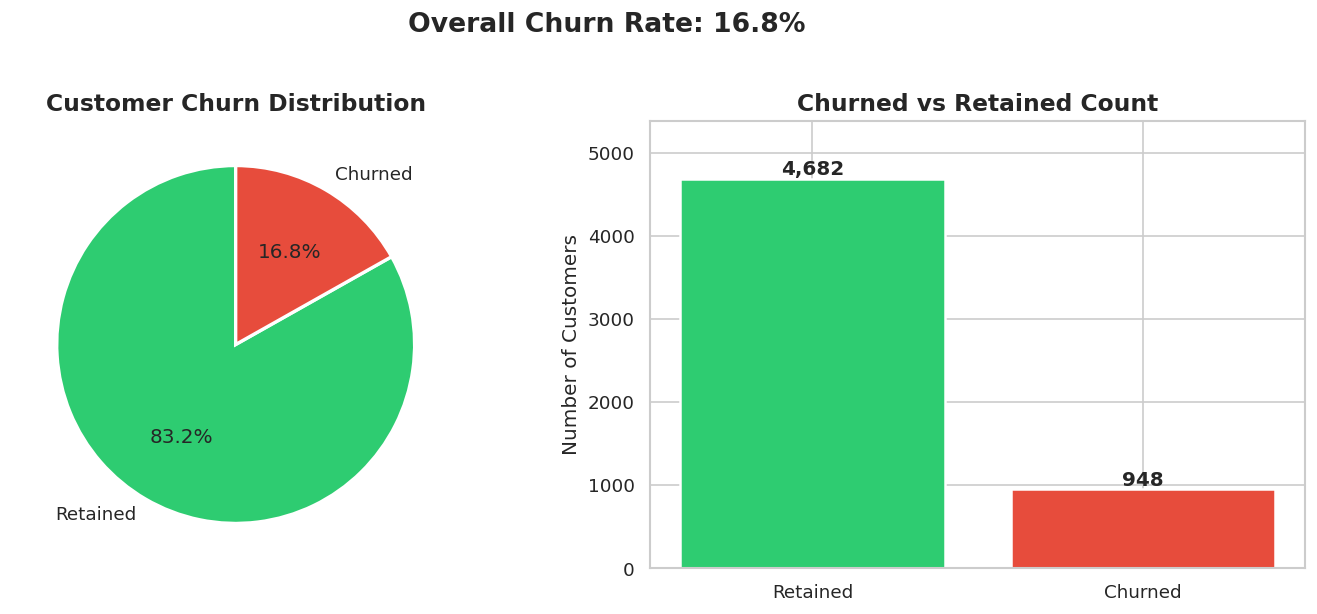


 Insight: Churn rate is 16.8% (948 out of 5,630 customers churned)


In [ ]:
churn_counts = df_clean['Churn'].value_counts()
churn_rate = df_clean['Churn'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie Chart
labels = ['Retained', 'Churned']
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

# Bar Chart
bars = axes[1].bar(labels, churn_counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, churn_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Churned vs Retained Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, max(churn_counts) * 1.15)

plt.suptitle(f'Overall Churn Rate: {churn_rate:.1f}%', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n Insight: Churn rate is {churn_rate:.1f}% ({churn_counts[1]:,} out of {len(df_clean):,} customers churned)')

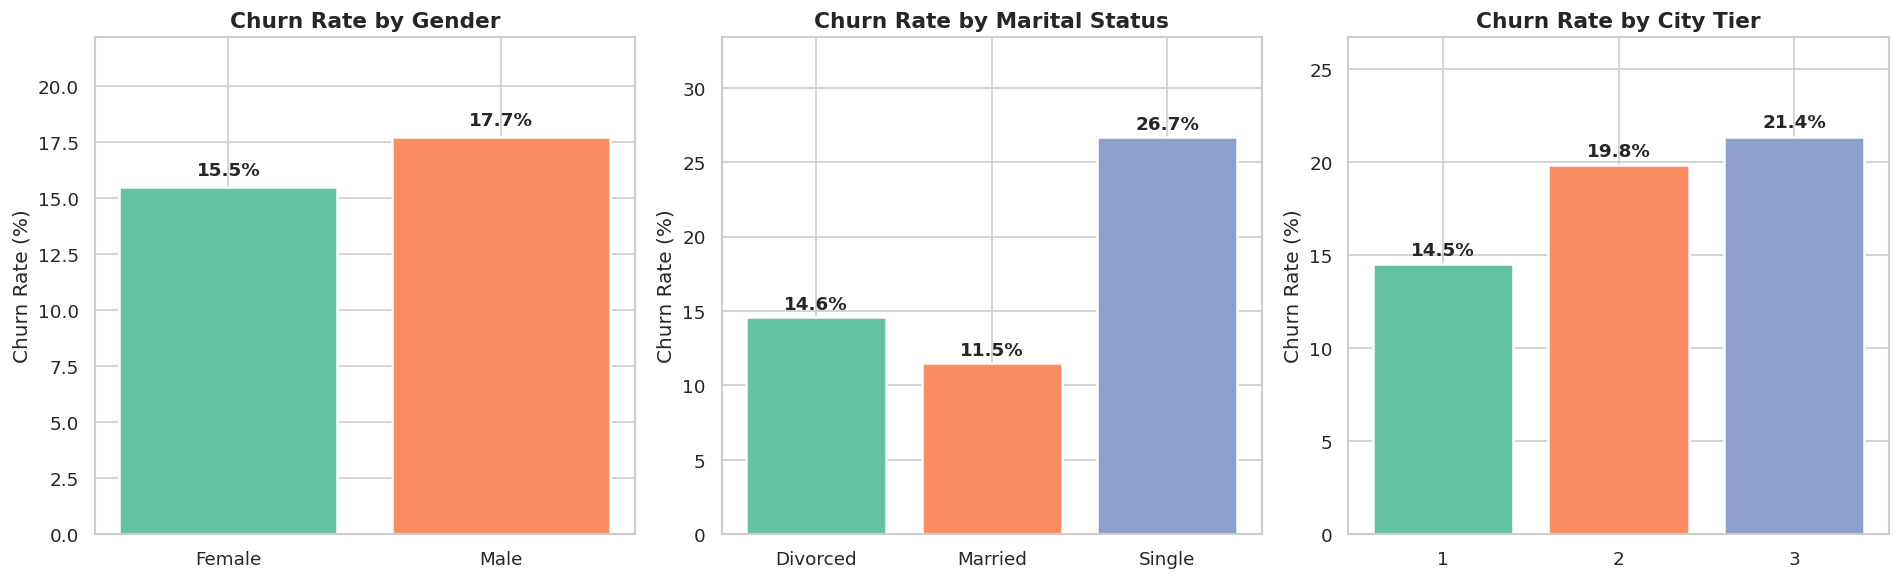

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_cols = ['Gender', 'MaritalStatus', 'CityTier']
titles = ['Gender', 'Marital Status', 'City Tier']

for ax, col, title in zip(axes, cat_cols, titles):
    churn_by = df_clean.groupby(col)['Churn'].mean() * 100
    bars = ax.bar(churn_by.index.astype(str), churn_by.values,
                  color=sns.color_palette('Set2', len(churn_by)),
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, churn_by.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(f'Churn Rate by {title}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, max(churn_by.values) * 1.25)

plt.tight_layout()
plt.show()

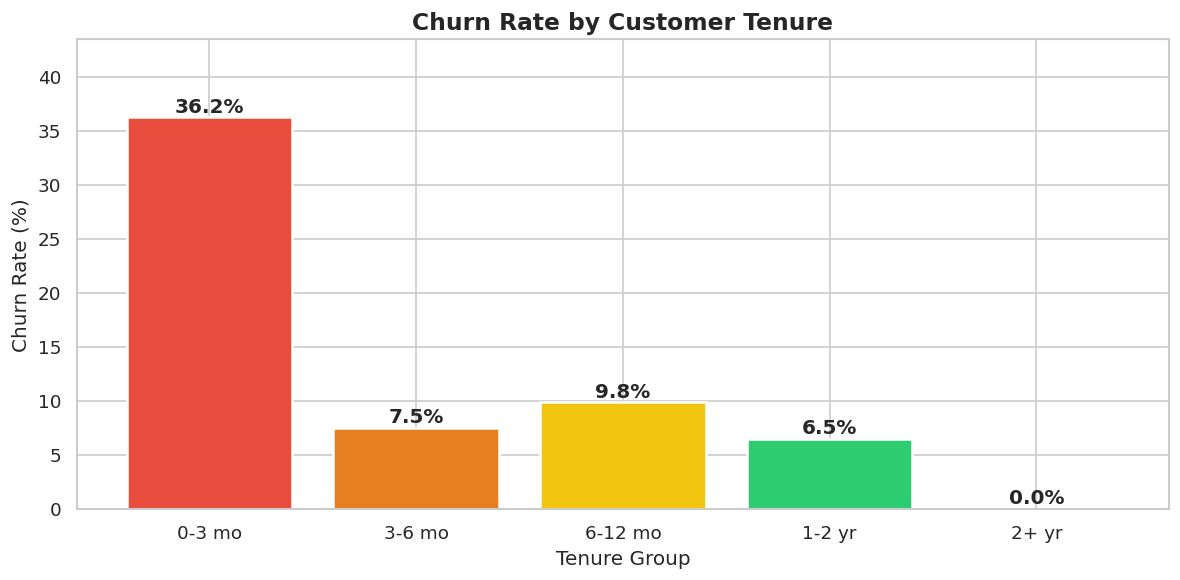


 Insight: New customers (0–3 months) have the highest churn rate.
  → Early engagement programs are critical to retain new customers.


In [ ]:
# Bin tenure into groups
df_clean['TenureGroup'] = pd.cut(df_clean['Tenure'],
                                  bins=[0, 3, 6, 12, 24, 100],
                                  labels=['0-3 mo', '3-6 mo', '6-12 mo', '1-2 yr', '2+ yr'])

tenure_churn = df_clean.groupby('TenureGroup', observed=True)['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(tenure_churn.index, tenure_churn.values,
              color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'],
              edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

ax.set_title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, max(tenure_churn.values) * 1.2)

plt.tight_layout()
plt.show()

print('\n Insight: New customers (0–3 months) have the highest churn rate.')
print('  → Early engagement programs are critical to retain new customers.')

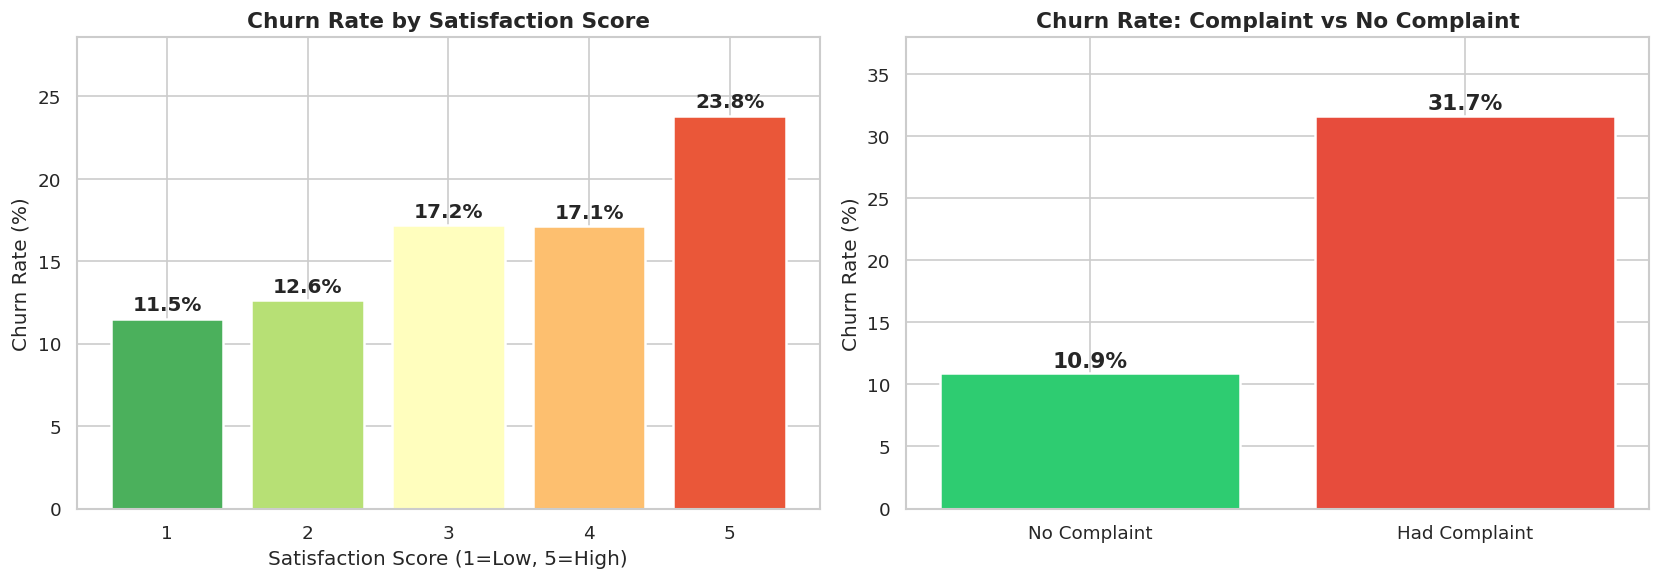


 Insight: Customers who filed complaints churn significantly more.
  → Fast complaint resolution is a key lever to reduce churn.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Satisfaction Score
sat_churn = df_clean.groupby('SatisfactionScore')['Churn'].mean() * 100
axes[0].bar(sat_churn.index, sat_churn.values,
            color=sns.color_palette('RdYlGn_r', 5), edgecolor='white', linewidth=1.5)
for i, val in enumerate(sat_churn.values):
    axes[0].text(sat_churn.index[i], val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by Satisfaction Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Satisfaction Score (1=Low, 5=High)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, max(sat_churn.values) * 1.2)

# Complaints
complain_churn = df_clean.groupby('Complain')['Churn'].mean() * 100
bars = axes[1].bar(['No Complaint', 'Had Complaint'], complain_churn.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, complain_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Churn Rate: Complaint vs No Complaint', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, max(complain_churn.values) * 1.2)

plt.tight_layout()
plt.show()

print('\n Insight: Customers who filed complaints churn significantly more.')
print('  → Fast complaint resolution is a key lever to reduce churn.')

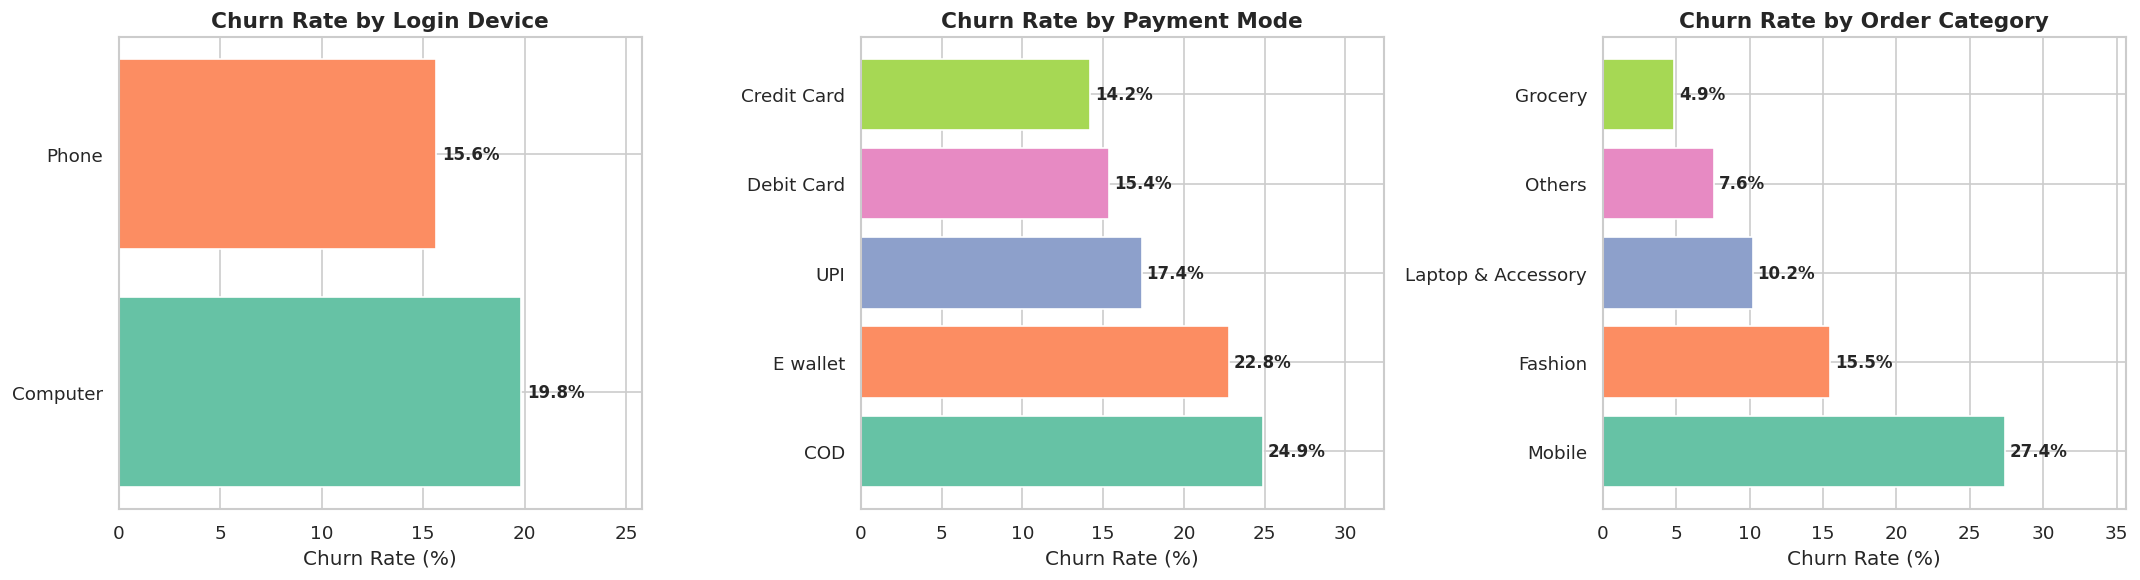

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_features = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']
cat_titles = ['Login Device', 'Payment Mode', 'Order Category']

for ax, col, title in zip(axes, cat_features, cat_titles):
    churn_by = df_clean.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = ax.barh(churn_by.index, churn_by.values,
                   color=sns.color_palette('Set2', len(churn_by)))
    for bar, val in zip(bars, churn_by.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
    ax.set_title(f'Churn Rate by {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_xlim(0, max(churn_by.values) * 1.3)

plt.tight_layout()
plt.show()

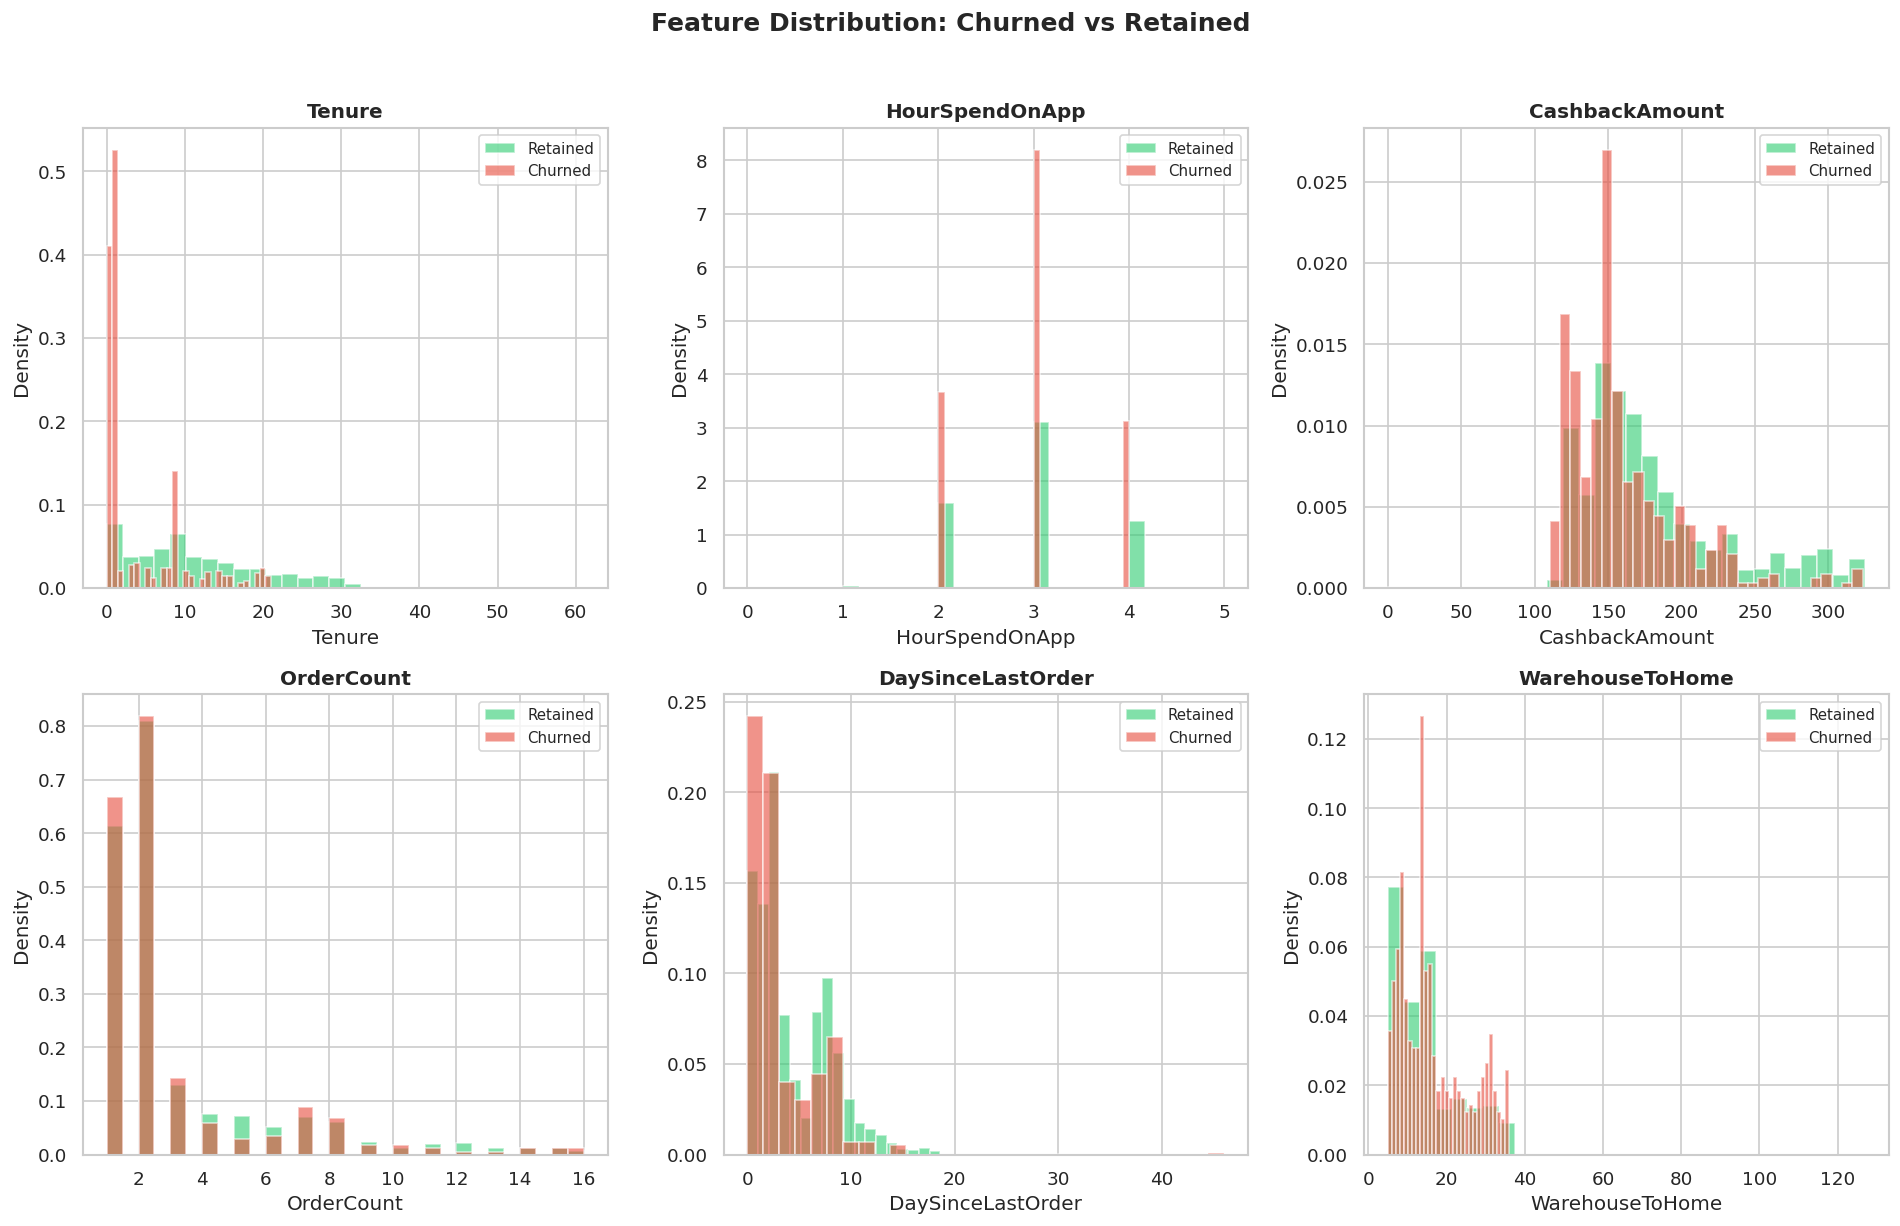

In [ ]:
num_features = ['Tenure', 'HourSpendOnApp', 'CashbackAmount',
                'OrderCount', 'DaySinceLastOrder', 'WarehouseToHome']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

churned = df_clean[df_clean['Churn'] == 1]
retained = df_clean[df_clean['Churn'] == 0]

for ax, col in zip(axes, num_features):
    ax.hist(retained[col], bins=30, alpha=0.6, color='#2ecc71', label='Retained', density=True)
    ax.hist(churned[col], bins=30, alpha=0.6, color='#e74c3c', label='Churned', density=True)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distribution: Churned vs Retained', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

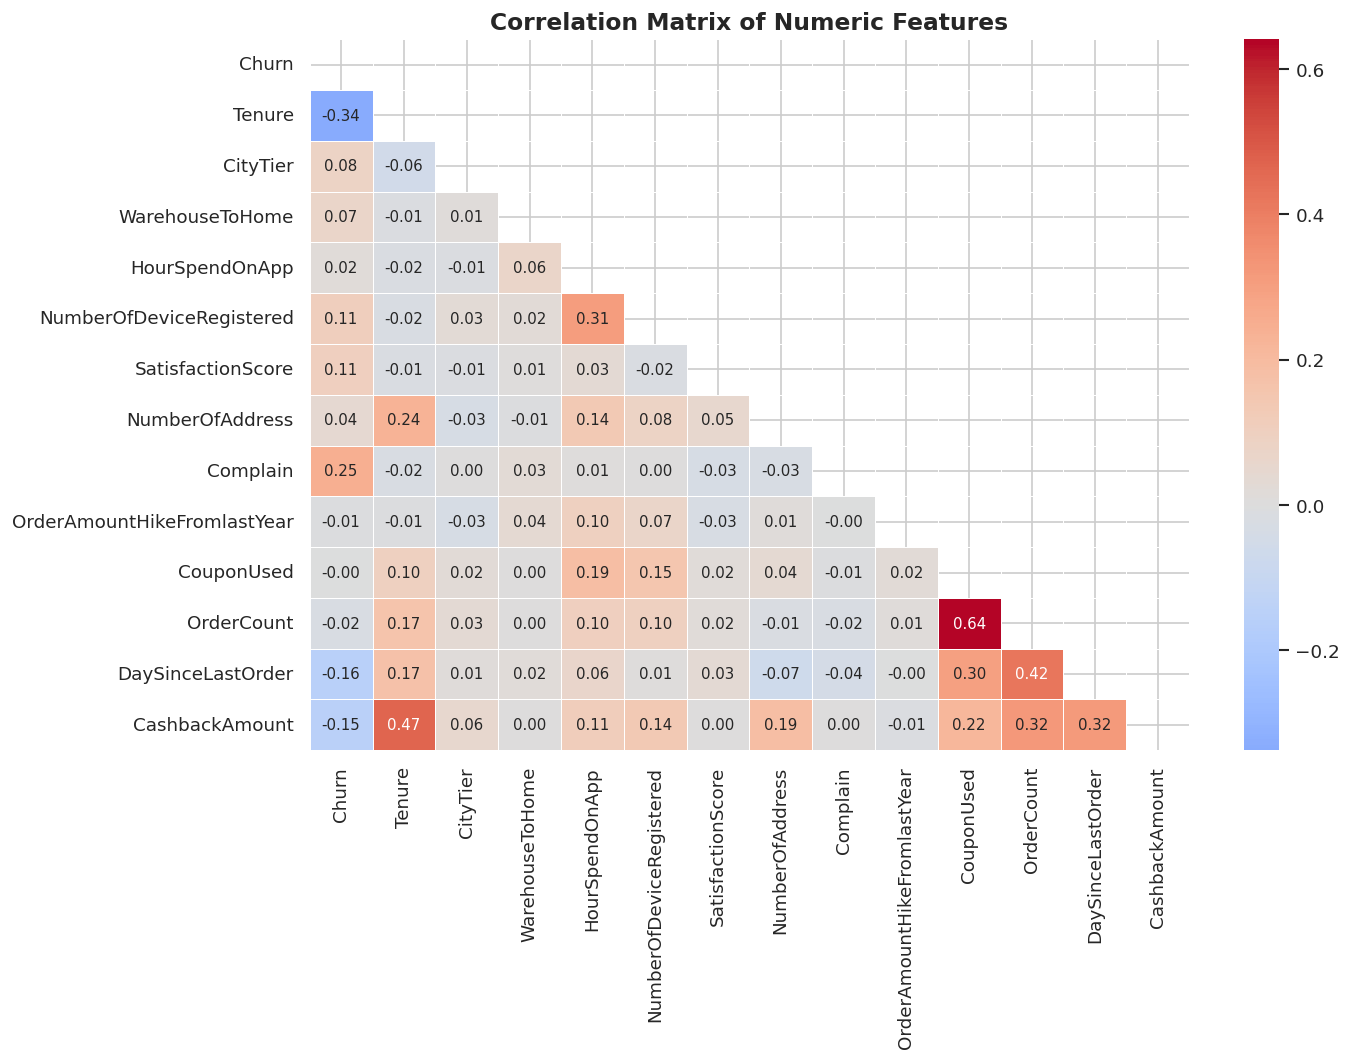


 Top Features Correlated with Churn:
Tenure                     -0.337831
Complain                    0.250188
DaySinceLastOrder          -0.155871
CashbackAmount             -0.154118
NumberOfDeviceRegistered    0.107939
SatisfactionScore           0.105481
CityTier                    0.084703
WarehouseToHome             0.069544


In [ ]:
num_df = df_clean.select_dtypes(include='number').drop('CustomerID', axis=1)
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with Churn
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print('\n Top Features Correlated with Churn:')
print(churn_corr.head(8).to_string())

In [ ]:
summary = df_clean.groupby('Churn')[num_features].mean().round(2)
summary.index = ['Retained (0)', 'Churned (1)']
summary['Count'] = df_clean['Churn'].value_counts().values

print('=== MEAN COMPARISON: Churned vs Retained ===')
display(summary)

=== MEAN COMPARISON: Churned vs Retained ===


,Tenure,HourSpendOnApp,CashbackAmount,OrderCount,DaySinceLastOrder,WarehouseToHome,Count
Retained (0),11.40,2.93,180.64,2.99,4.71,15.31,4682
Churned (1),3.86,2.96,160.37,2.81,3.22,16.86,948


In [ ]:
df_clean.to_csv('ecommerce_churn_clean.csv', index=False)
print(' Clean dataset exported as: ecommerce_churn_clean.csv')
print(f'   Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

 Clean dataset exported as: ecommerce_churn_clean.csv
   Shape: 5,630 rows × 21 columns


In [ ]:
# Cashback per Order: Rasio keuntungan ekonomi yang dirasakan pelanggan
df_clean['CashbackPerOrder'] = df_clean['CashbackAmount'] / (df_clean['OrderCount'] + 1)

# Engagement Score: Seberapa 'lengket' pelanggan dengan platform
df_clean['EngagementScore'] = df_clean['HourSpendOnApp'] * df_clean['NumberOfDeviceRegistered']

# At-Risk Index: Menggabungkan kepuasan rendah dengan adanya komplain
# Rumus: (6 - Skor) * (Komplain + 1). Semakin tinggi, semakin berisiko.
df_clean['AtRiskIndex'] = (6 - df_clean['SatisfactionScore']) * (df_clean['Complain'] + 1)

print(" Feature Engineering Berhasil! Kolom baru ditambahkan.")
display(df_clean[['CashbackPerOrder', 'EngagementScore', 'AtRiskIndex']].head())

 Feature Engineering Berhasil! Kolom baru ditambahkan.


,CashbackPerOrder,EngagementScore,AtRiskIndex
0,79.965,9.0,8
1,60.450,12.0,6
2,60.140,8.0,6
3,67.035,8.0,1
4,64.800,9.0,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# A. Pre-processing: Mengubah teks menjadi angka (One-Hot Encoding)
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
df_model = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# B. Memisahkan Fitur (X) dan Target (y)
# Hapus ID dan kolom kategori lama yang sudah di-encode
X = df_model.drop(['CustomerID', 'Churn', 'TenureGroup'], axis=1)
y = df_model['Churn']

# C. Splitting Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# D. Membangun Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# E. Prediksi dan Evaluasi
y_pred = rf_model.predict(X_test)

print("=== MODEL PERFORMANCE ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== MODEL PERFORMANCE ===
Accuracy Score: 98.40%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       936
           1       0.98      0.93      0.95       190

    accuracy                           0.98      1126
   macro avg       0.98      0.96      0.97      1126
weighted avg       0.98      0.98      0.98      1126



/tmp/ipykernel_3954/3768384741.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


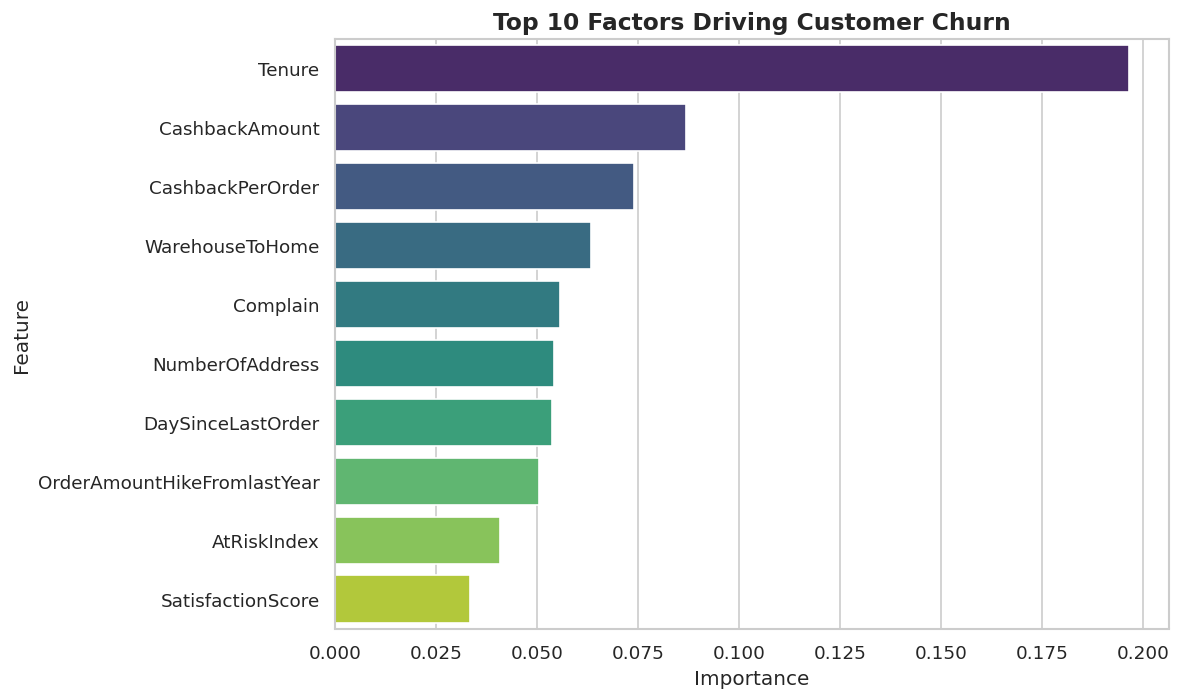

In [ ]:
# Mengambil tingkat kepentingan fitur
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Visualisasi 10 Fitur Teratas
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Factors Driving Customer Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Menghitung probabilitas churn untuk seluruh dataset
# predict_proba mengembalikan dua kolom: [Probabilitas Tetap, Probabilitas Churn]
# Kita ambil [:, 1] untuk mendapatkan skor risiko (0.0 sampai 1.0)
df_clean['Churn_Probability'] = rf_model.predict_proba(X)[:, 1]

# 2. Menambahkan label prediksi final (0 atau 1) berdasarkan model
df_clean['Churn_Prediction'] = rf_model.predict(X)

# 3. Membuat kolom "Risk Segment" untuk mempermudah visualisasi di Dashboard
# Ini akan sangat berguna di Tableau/Power BI nanti
def segment_risk(prob):
    if prob >= 0.7: return 'High Risk'
    elif prob >= 0.3: return 'Medium Risk'
    else: return 'Low Risk'

df_clean['Risk_Segment'] = df_clean['Churn_Probability'].apply(segment_risk)

# 4. Export ke CSV baru
df_clean.to_csv('ecommerce_churn_final_prediction.csv', index=False)

print(" File 'ecommerce_churn_final_prediction.csv' berhasil dibuat!")
print("Kolom baru: Churn_Probability, Churn_Prediction, dan Risk_Segment.")

 File 'ecommerce_churn_final_prediction.csv' berhasil dibuat!
Kolom baru: Churn_Probability, Churn_Prediction, dan Risk_Segment.
